#Libraries & Data Loading

In [ ]:
#Connecting to drive:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/BARQ/

/content/drive/MyDrive/BARQ


In [ ]:
#Libraries Loading
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#Exploratory Data Analysis (EDA)


##Data Loading & Initial Exploration

In [195]:
#Loading the CSV file
df_netflix = pd.read_csv('netflix_titles.csv')
df_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [196]:
df_netflix.shape

(8807, 12)

In [197]:
#Summary of the numeric variables
df_netflix.describe().T

,count,mean,std,min,25%,50%,75%,max
release_year,8807.0,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0


In [198]:
#Checking data types for each column
df_netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


###**Comments**
`Date Added` variable data type needs to be adjusted!

##Data Cleaning

### Adjusting the Date column data type:

In [199]:
#Concatenating Date and Time in one column and adjusting the data type
df_netflix['date_added'] = pd.to_datetime(df_netflix['date_added'], format="mixed")
df_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [200]:
df_netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


### Keeping only the relevant columns for analysis - Remove Description Column

In [201]:
df_netflix.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [202]:
df_netflix = df_netflix.drop('description', axis=1)
df_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


### Checking unique values in some columns for cleaning purposes

In [203]:
df_netflix['release_year'].unique()
#Sort values based on release year

array([2020, 2021, 1993, 2018, 1996, 1998, 1997, 2010, 2013, 2017, 1975,
       1978, 1983, 1987, 2012, 2001, 2014, 2002, 2003, 2004, 2011, 2008,
       2009, 2007, 2005, 2006, 1994, 2015, 2019, 2016, 1982, 1989, 1990,
       1991, 1999, 1986, 1992, 1984, 1980, 1961, 2000, 1995, 1985, 1976,
       1959, 1988, 1981, 1972, 1964, 1945, 1954, 1979, 1958, 1956, 1963,
       1970, 1973, 1925, 1974, 1960, 1966, 1971, 1962, 1969, 1977, 1967,
       1968, 1965, 1946, 1942, 1955, 1944, 1947, 1943])

In [204]:
df_netflix['rating'].unique()
#Some data entry issues (runtime instead of rating) --> convert to NULL!
#Categorize this column into 'Kids/Family', 'Teens', 'Adults'

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR'], dtype=object)

In [205]:
df_netflix['duration'].unique()

# mins for Movies Cat.
# no. of seasons for TV shows Cat.

#Separate into two columns 1. Movie runtime  2. TV show seasons

array(['90 min', '2 Seasons', '1 Season', '91 min', '125 min',
       '9 Seasons', '104 min', '127 min', '4 Seasons', '67 min', '94 min',
       '5 Seasons', '161 min', '61 min', '166 min', '147 min', '103 min',
       '97 min', '106 min', '111 min', '3 Seasons', '110 min', '105 min',
       '96 min', '124 min', '116 min', '98 min', '23 min', '115 min',
       '122 min', '99 min', '88 min', '100 min', '6 Seasons', '102 min',
       '93 min', '95 min', '85 min', '83 min', '113 min', '13 min',
       '182 min', '48 min', '145 min', '87 min', '92 min', '80 min',
       '117 min', '128 min', '119 min', '143 min', '114 min', '118 min',
       '108 min', '63 min', '121 min', '142 min', '154 min', '120 min',
       '82 min', '109 min', '101 min', '86 min', '229 min', '76 min',
       '89 min', '156 min', '112 min', '107 min', '129 min', '135 min',
       '136 min', '165 min', '150 min', '133 min', '70 min', '84 min',
       '140 min', '78 min', '7 Seasons', '64 min', '59 min', '139 min',
    

In [206]:
df_netflix['listed_in'].unique()
#One Hot Encoding for the genres!

array(['Documentaries', 'International TV Shows, TV Dramas, TV Mysteries',
       'Crime TV Shows, International TV Shows, TV Action & Adventure',
       'Docuseries, Reality TV',
       'International TV Shows, Romantic TV Shows, TV Comedies',
       'TV Dramas, TV Horror, TV Mysteries', 'Children & Family Movies',
       'Dramas, Independent Movies, International Movies',
       'British TV Shows, Reality TV', 'Comedies, Dramas',
       'Crime TV Shows, Docuseries, International TV Shows',
       'Dramas, International Movies',
       'Children & Family Movies, Comedies',
       'British TV Shows, Crime TV Shows, Docuseries',
       'TV Comedies, TV Dramas', 'Documentaries, International Movies',
       'Crime TV Shows, Spanish-Language TV Shows, TV Dramas',
       'Thrillers',
       'International TV Shows, Spanish-Language TV Shows, TV Action & Adventure',
       'International TV Shows, TV Action & Adventure, TV Dramas',
       'Comedies, International Movies',
       'Comedies, 

In [207]:
df_netflix['country'].unique()
df_netflix['director'].unique()
df_netflix['cast'].unique()

#Consider some cleaning like fixing typos, comma separation, strip spacing for the country, cast, director columns

array([nan,
       'Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng',
       'Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera',
       ...,
       'Jesse Eisenberg, Woody Harrelson, Emma Stone, Abigail Breslin, Amber Heard, Bill Murray, Derek Graf',
       'Tim Allen, Courteney Cox, Chevy Chase, Kate Mara, Ryan Newman, Michael Cassidy, Spencer Breslin, Rip Torn, Kevin Zegers',
       'Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanana, Manish Chaudhary, Meghna Malik, Malkeet Rauni, Anita Shabdish, Chittaranjan Tripathy'],
      dtype=object)

In [208]:
df_netflix['type'].unique()
# No further cleaning needed!

array(['Movie', 'TV Show'], dtype=object)

### Checking Null Values:

In [209]:
df_netflix.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


### Comments
will decide whether impute/drop some values in columns `duration`, `date_added`, `rating` after research


### Checking duplicate Values:

In [210]:
df_netflix.duplicated().sum()
# No duplicated columns!

np.int64(0)

# Data Pre-processing

#### Rating Column

In [211]:
#Fixing data entry issues --> NUlls
df_netflix.loc[df_netflix['rating'].str.contains('min', case=False, na=False), 'rating'] = np.nan
df_netflix['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', nan, 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

In [212]:
#Create new column to categorize rating:
rating_map = {
    'TV-Y': 'Kids',
    'TV-Y7': 'Kids',
    'TV-Y7-FV': 'Kids',
    'TV-G': 'Kids',
    'G': 'Kids',
    'PG': 'Kids',
    'TV-PG': 'Kids',
    'PG-13': 'Teens',
    'TV-14': 'Teens',
    'R': 'Adults',
    'TV-MA': 'Adults',
    'NC-17': 'Adults',
    'NR': 'Unrated',
    'UR': 'Unrated'
}

df_netflix['rating_category'] = df_netflix['rating'].map(rating_map).fillna('Unrated')


In [213]:
# Remove the Rating column:
df_netflix = df_netflix.drop('rating', axis=1)
df_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,duration,listed_in,rating_category
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,90 min,Documentaries,Teens
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",Adults
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,1 Season,"Crime TV Shows, International TV Shows, TV Act...",Adults
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,1 Season,"Docuseries, Reality TV",Adults
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",Adults


#### Date Added Column

In [214]:
df_netflix.loc[df_netflix['date_added'].isnull()]
# Since they are only 10 rows, we drop them!

,show_id,type,title,director,cast,country,date_added,release_year,duration,listed_in,rating_category
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,NaN,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaT,2013,2 Seasons,"British TV Shows, TV Comedies, TV Dramas",Adults
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,NaN,Anthony Bourdain,United States,NaT,2018,5 Seasons,Docuseries,Kids
6795,s6796,TV Show,Frasier,NaN,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaT,2003,11 Seasons,"Classic & Cult TV, TV Comedies",Kids
6806,s6807,TV Show,Friends,NaN,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaT,2003,10 Seasons,"Classic & Cult TV, TV Comedies",Teens
6901,s6902,TV Show,Gunslinger Girl,NaN,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaT,2008,2 Seasons,"Anime Series, Crime TV Shows",Teens
7196,s7197,TV Show,Kikoriki,NaN,Igor Dmitriev,NaN,NaT,2010,2 Seasons,Kids' TV,Kids
7254,s7255,TV Show,La Familia P. Luche,NaN,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaT,2012,3 Seasons,"International TV Shows, Spanish-Language TV Sh...",Teens
7406,s7407,TV Show,Maron,NaN,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaT,2016,4 Seasons,TV Comedies,Adults
7847,s7848,TV Show,Red vs. Blue,NaN,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaT,2015,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...",Unrated
8182,s8183,TV Show,The Adventures of Figaro Pho,NaN,"Luke Jurevicius, Craig Behenna, Charlotte Haml...",Australia,NaT,2015,2 Seasons,"Kids' TV, TV Comedies",Kids


In [215]:
df_netflix = df_netflix.dropna(subset=['date_added'])
df_netflix.isnull().sum()

,0
show_id,0
type,0
title,0
director,2624
cast,825
country,830
date_added,0
release_year,0
duration,3
listed_in,0


#### Duration Column

In [216]:
df_netflix[df_netflix['duration'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,duration,listed_in,rating_category
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,NaN,Movies,Unrated
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,NaN,Movies,Unrated
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,NaN,Movies,Unrated


In [217]:
df_netflix[df_netflix['director'] == 'Louis C.K.']
#Since these rows have multiple columns of missing values, drop them

,show_id,type,title,director,cast,country,date_added,release_year,duration,listed_in,rating_category
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,NaN,Movies,Unrated
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,NaN,Movies,Unrated
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,NaN,Movies,Unrated


In [218]:
df_netflix = df_netflix.dropna(subset=['duration'])
df_netflix.isnull().sum()

,0
show_id,0
type,0
title,0
director,2624
cast,825
country,830
date_added,0
release_year,0
duration,0
listed_in,0


In [219]:
# Feature Extraction - Split the Duration into two columns
df_netflix['movie_runtime_mins'] = df_netflix['duration'].str.extract('(\d+) min', expand=False)
df_netflix['tv_show_seasons'] = df_netflix['duration'].str.extract('(\d+) Season', expand=False)

#NOTE: for visualization purposes, filter by TV show/ Movie for better insight

In [220]:
# Drop Duration Column
df_netflix = df_netflix.drop('duration', axis=1)
df_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,listed_in,rating_category,movie_runtime_mins,tv_show_seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Documentaries,Teens,90,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,"International TV Shows, TV Dramas, TV Mysteries",Adults,NaN,2
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,"Crime TV Shows, International TV Shows, TV Act...",Adults,NaN,1
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,"Docuseries, Reality TV",Adults,NaN,1
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,"International TV Shows, Romantic TV Shows, TV ...",Adults,NaN,2


#### Listed In Column - Genres

In [221]:
# Extract all different genres present in the dataset
all_genres = (
    df_netflix['listed_in']
    .dropna()
    .apply(lambda x: [genre.strip() for genre in x.split(',')])
    .explode()
    .unique()
)

# Convert to list and sort
all_genres = sorted(all_genres)

print(all_genres)
print(f"Total unique genres: {len(all_genres)}")

['Action & Adventure', 'Anime Features', 'Anime Series', 'British TV Shows', 'Children & Family Movies', 'Classic & Cult TV', 'Classic Movies', 'Comedies', 'Crime TV Shows', 'Cult Movies', 'Documentaries', 'Docuseries', 'Dramas', 'Faith & Spirituality', 'Horror Movies', 'Independent Movies', 'International Movies', 'International TV Shows', "Kids' TV", 'Korean TV Shows', 'LGBTQ Movies', 'Movies', 'Music & Musicals', 'Reality TV', 'Romantic Movies', 'Romantic TV Shows', 'Sci-Fi & Fantasy', 'Science & Nature TV', 'Spanish-Language TV Shows', 'Sports Movies', 'Stand-Up Comedy', 'Stand-Up Comedy & Talk Shows', 'TV Action & Adventure', 'TV Comedies', 'TV Dramas', 'TV Horror', 'TV Mysteries', 'TV Sci-Fi & Fantasy', 'TV Shows', 'TV Thrillers', 'Teen TV Shows', 'Thrillers']
Total unique genres: 42


In [222]:
#Explode a COPY of the dataframe for EDA visualizations --- NO ADJUSTMENT ON THE ORIGINAL DATASET
df_netflix_exploded = df_netflix
df_netflix_exploded['listed_in'] = df_netflix_exploded['listed_in'].dropna().apply(lambda x: [g.strip() for g in x.split(',')])
df_genres = df_netflix_exploded.explode('listed_in')

In [223]:
genre_counts = df_genres['listed_in'].value_counts().head(10)
genre_counts

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1350
Documentaries,869
Action & Adventure,859
TV Dramas,762
Independent Movies,756
Children & Family Movies,641


#### Extract Time Features

In [224]:
df_netflix['year_added'] = df_netflix['date_added'].dt.year
df_netflix['month_added'] = df_netflix['date_added'].dt.month
df_netflix['day_added'] = df_netflix['date_added'].dt.day
df_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,listed_in,rating_category,movie_runtime_mins,tv_show_seasons,year_added,month_added,day_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,[Documentaries],Teens,90,NaN,2021,9,25
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,"[International TV Shows, TV Dramas, TV Mysteries]",Adults,NaN,2,2021,9,24
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,"[Crime TV Shows, International TV Shows, TV Ac...",Adults,NaN,1,2021,9,24
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,"[Docuseries, Reality TV]",Adults,NaN,1,2021,9,24
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,"[International TV Shows, Romantic TV Shows, TV...",Adults,NaN,2,2021,9,24


#### Cast Column

In [226]:
#Explode a COPY of the dataframe for EDA visualizations --- NO ADJUSTMENT ON THE ORIGINAL DATASET
df_netflix_exploded_cast = df_netflix
df_netflix_exploded_cast['cast'] = df_netflix_exploded_cast['cast'].dropna().apply(lambda x: [g.strip() for g in x.split(',')])
df_cast = df_netflix_exploded_cast.explode('cast')

In [227]:
cast_counts = df_cast['cast'].value_counts().head(10)
cast_counts

,count
cast,
Anupam Kher,43
Shah Rukh Khan,35
Julie Tejwani,33
Naseeruddin Shah,32
Takahiro Sakurai,32
Rupa Bhimani,31
Akshay Kumar,30
Om Puri,30
Yuki Kaji,29


#### Country Column

In [228]:
#Explode a COPY of the dataframe for EDA visualizations --- NO ADJUSTMENT ON THE ORIGINAL DATASET
df_netflix_exploded_country = df_netflix
df_netflix_exploded_country['country'] = df_netflix_exploded_country['country'].dropna().apply(lambda x: [g.strip() for g in x.split(',')])
df_country = df_netflix_exploded_country.explode('country')

In [229]:
country_counts = df_country['country'].value_counts().head(10)
country_counts

,count
country,
United States,3681
India,1046
United Kingdom,805
Canada,445
France,393
Japan,317
Spain,232
South Korea,231
Germany,226


#### Director Column

In [230]:
#Explode a COPY of the dataframe for EDA visualizations --- NO ADJUSTMENT ON THE ORIGINAL DATASET
df_netflix_exploded_director = df_netflix
df_netflix_exploded_director['director'] = df_netflix_exploded_director['director'].dropna().apply(lambda x: [g.strip() for g in x.split(',')])
df_director = df_netflix_exploded_director.explode('director')

In [231]:
director_counts = df_director['director'].value_counts().head(10)
director_counts

,count
director,
Rajiv Chilaka,22
Jan Suter,21
Raúl Campos,19
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,15
Cathy Garcia-Molina,13
Jay Chapman,12
Martin Scorsese,12


### Comments
For ML, do binary/ one hot encoding for accurate results

### Back to Null imputation

In [232]:
df_netflix.isnull().sum()

,0
show_id,0
type,0
title,0
director,2624
cast,825
country,830
date_added,0
release_year,0
listed_in,0
rating_category,0


#### Columns `movie_runtime_mins`, `tv_show_seasons` replace missing values with 'Unknown' for better insight

In [ ]:
df_netflix['movie_runtime_mins'] = df_netflix['movie_runtime_mins'].fillna('Unknown')
df_netflix['tv_show_seasons'] = df_netflix['tv_show_seasons'].fillna('Unknown')


In [234]:
df_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,listed_in,rating_category,movie_runtime_mins,tv_show_seasons,year_added,month_added,day_added
0,s1,Movie,Dick Johnson Is Dead,[Kirsten Johnson],NaN,[United States],2021-09-25,2020,[Documentaries],Teens,90,Unknown,2021,9,25
1,s2,TV Show,Blood & Water,NaN,"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba...",[South Africa],2021-09-24,2021,"[International TV Shows, TV Dramas, TV Mysteries]",Adults,Unknown,2,2021,9,24
2,s3,TV Show,Ganglands,[Julien Leclercq],"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nab...",NaN,2021-09-24,2021,"[Crime TV Shows, International TV Shows, TV Ac...",Adults,Unknown,1,2021,9,24
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,"[Docuseries, Reality TV]",Adults,Unknown,1,2021,9,24
4,s5,TV Show,Kota Factory,NaN,"[Mayur More, Jitendra Kumar, Ranjan Raj, Alam ...",[India],2021-09-24,2021,"[International TV Shows, Romantic TV Shows, TV...",Adults,Unknown,2,2021,9,24


In [235]:
df_netflix.isnull().sum()
# Since we have filled all columns except these three: director, cast, country

,0
show_id,0
type,0
title,0
director,2624
cast,825
country,830
date_added,0
release_year,0
listed_in,0
rating_category,0


## Data Visualization

### **Numerical Variables:**
`Release_year`,
`year_added`,
`month_added`,
`day_added`,
`tv_shows_seasons`,
`movie_runtime_minutes`

In [ ]:
#Function to Plot Histograms given the dataframe and the column name:
def Histogram(df, col):
  df_Histogram = df[col]

  plt.figure(figsize= (10,6))
  sns.histplot(df_Histogram, bins = 50, kde= True, color= 'orchid')
  plt.xlabel(f'{col}')
  plt.ylabel('Frequency')
  plt.title(f'Histogram of {col} Column')

  plt.show()

In [ ]:
#Function to Plot Boxplots given the dataframe and the column name:
def Boxplot(df, col):
  df_Boxplot = df[col]

  plt.figure(figsize=(6, 4))
  sns.boxplot(x=df[col], color = 'orange')
  plt.title(f'Boxplot of {col} Column', fontsize=14)
  plt.xlabel(f'{col}')

  plt.show()

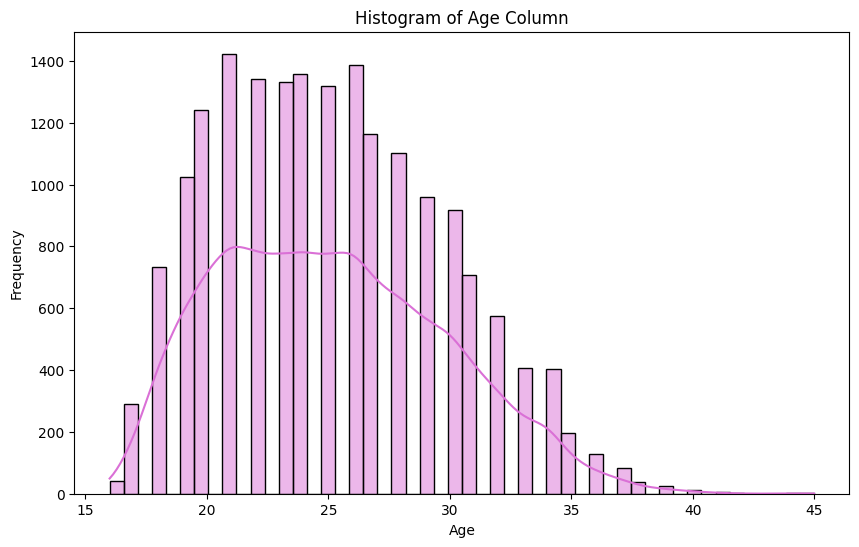

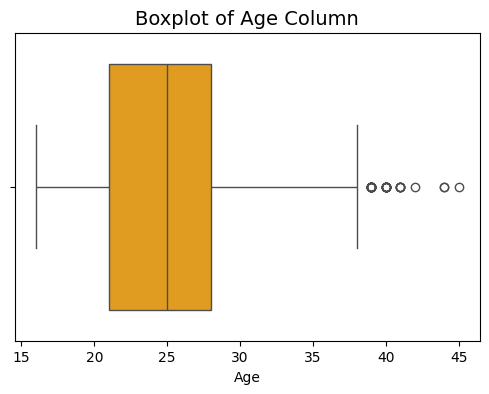

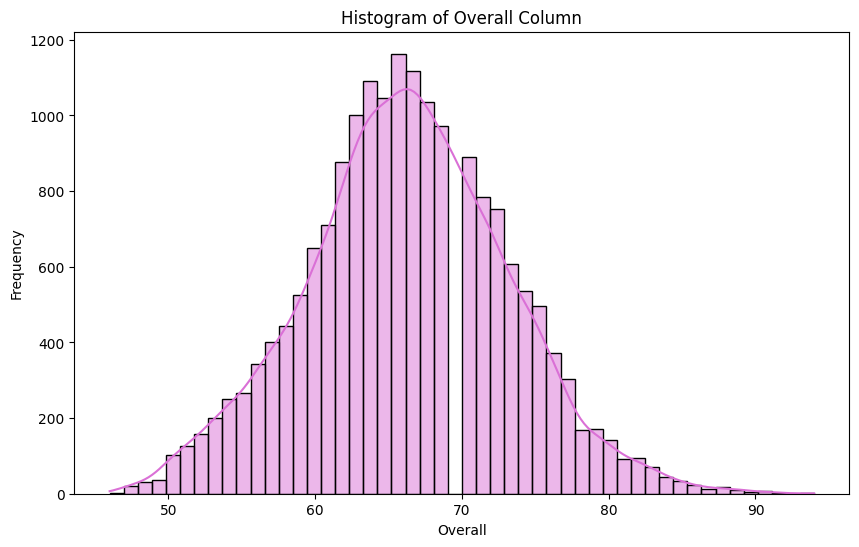

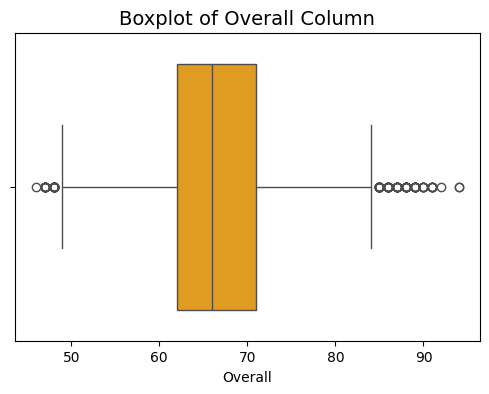

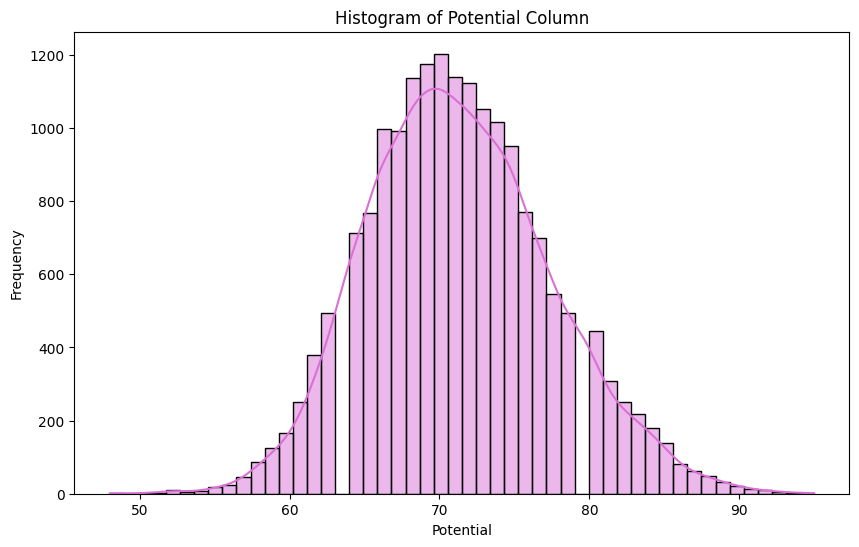

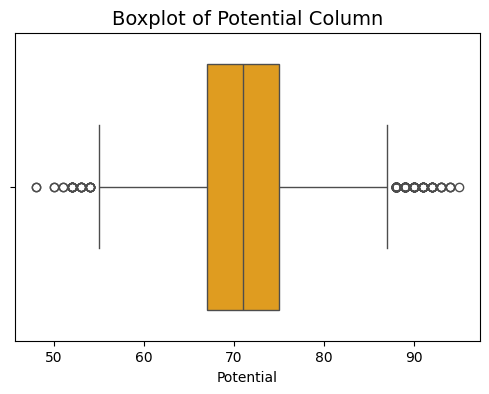

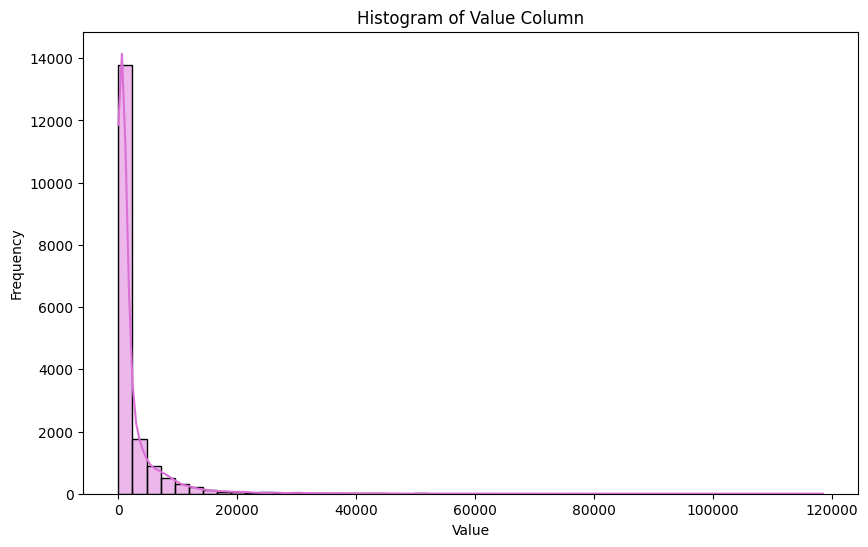

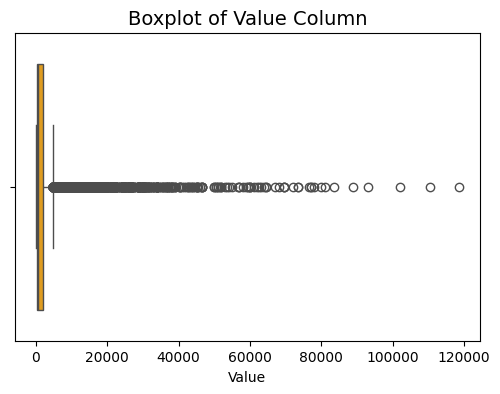

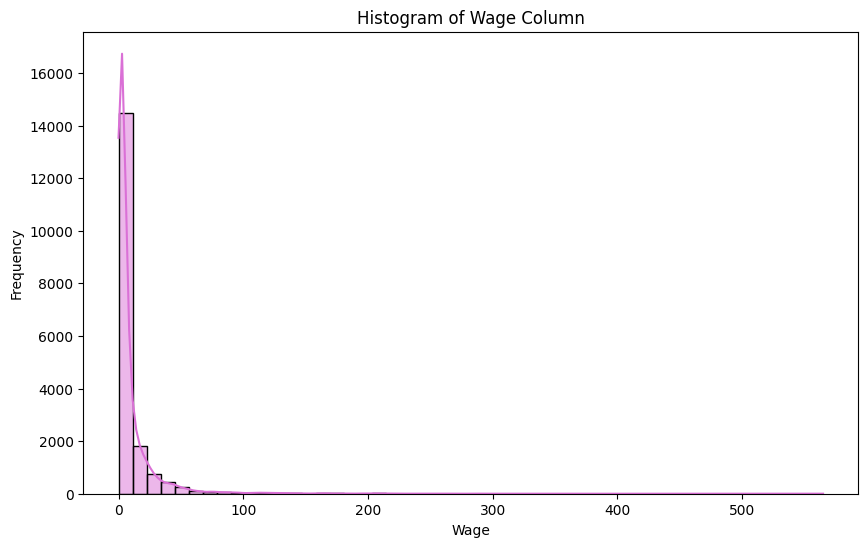

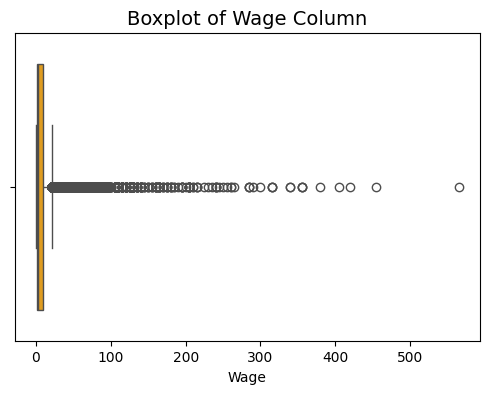

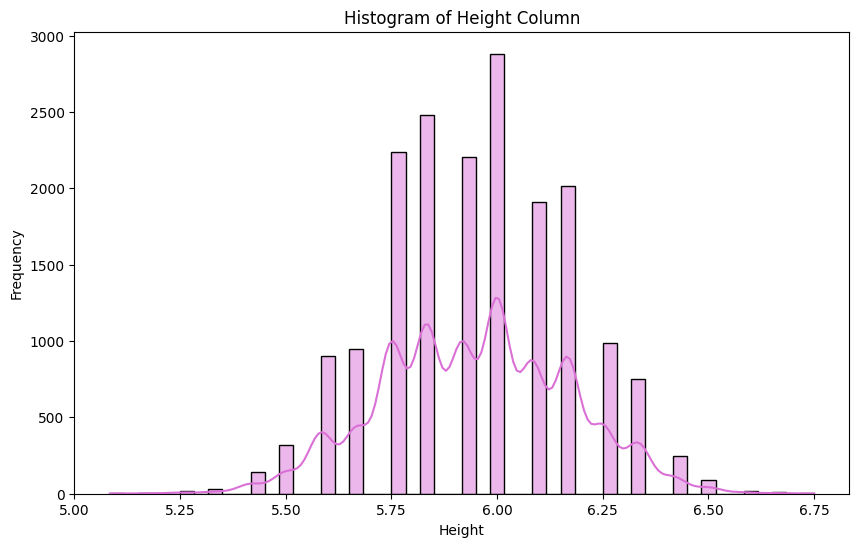

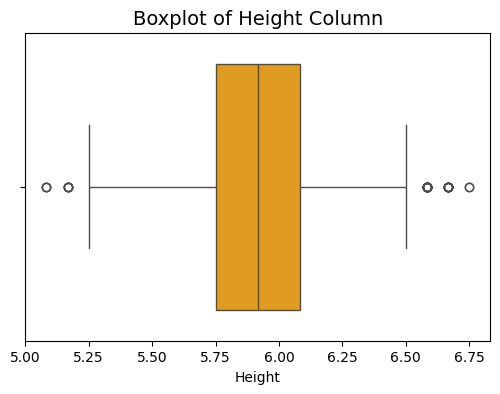

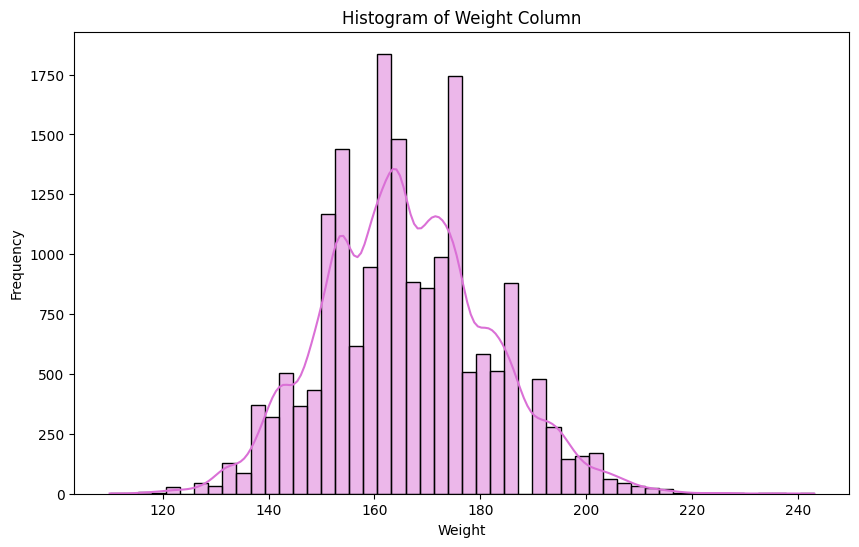

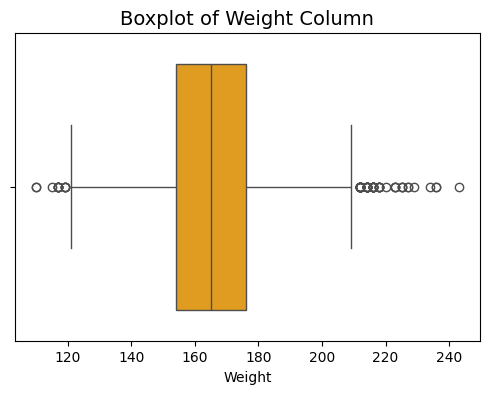

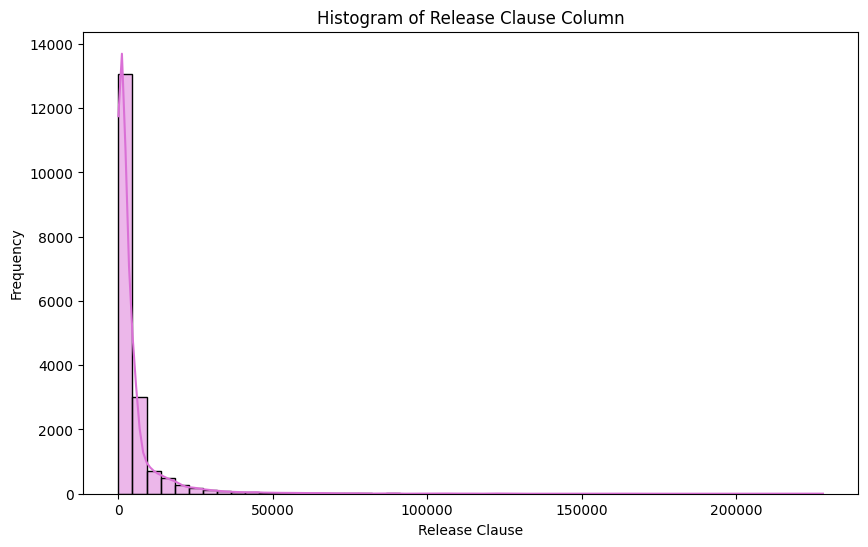

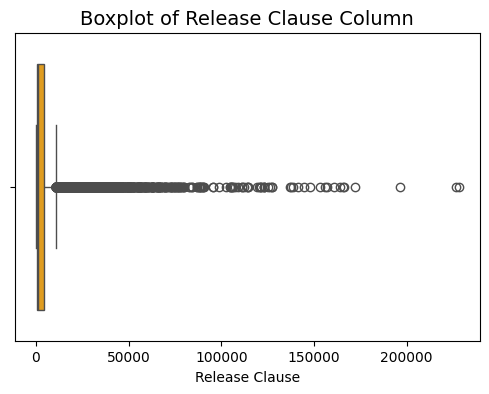

In [ ]:
#Barchart of Numerical Variables:
numerical_cols = ['Age', 'Overall', 'Potential', 'Value', 'Wage','Height', 'Weight', 'Release Clause']
for col in numerical_cols:
  Histogram(df, col)
  Boxplot(df, col)

**Categorical Variables:**

`rating_category`,
`listed_in`,
`country`,
`cast`,
`director`,
`title`,
`type`

In [ ]:
#Function to Plot Barcharts given the dataframe and the column name:
def BarPlot(df, col):
  plt.figure(figsize=(10, 6))
  df_Barchart = df[col].value_counts().head(10)
  df_Barchart.plot(kind = 'bar', color= 'purple' )

  plt.title(f'Barchart of {col} Column',  fontsize= 16)
  plt.xlabel(f'{col}', fontsize= 14)
  plt.ylabel('Total Players', fontsize= 14)

  plt.show()

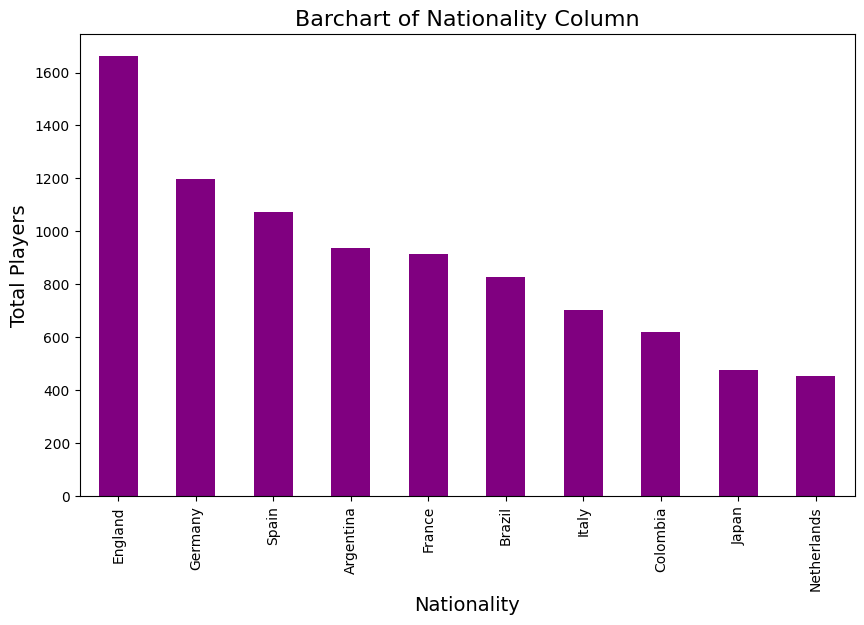

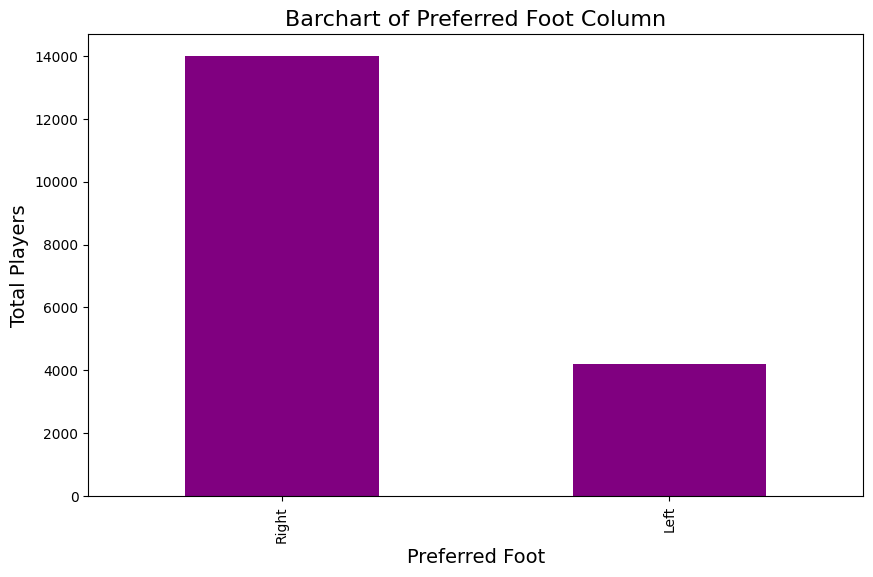

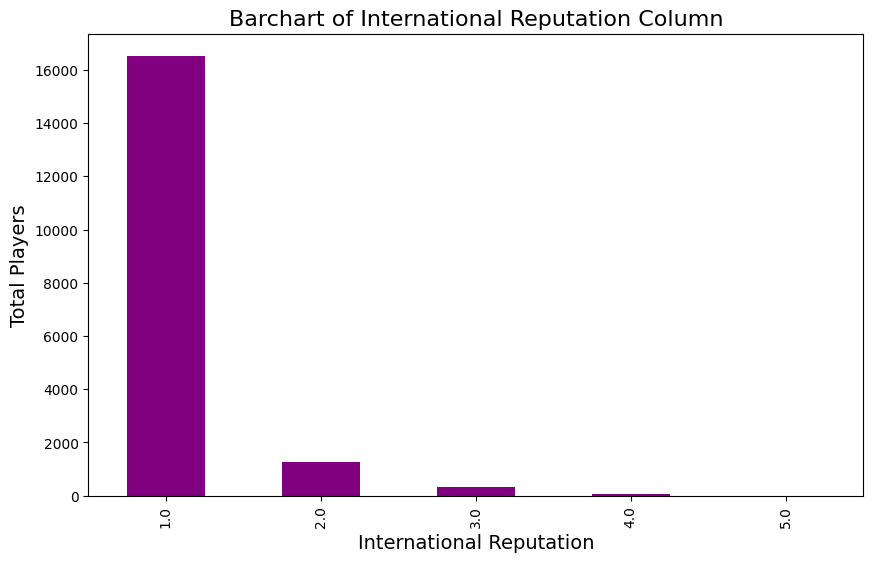

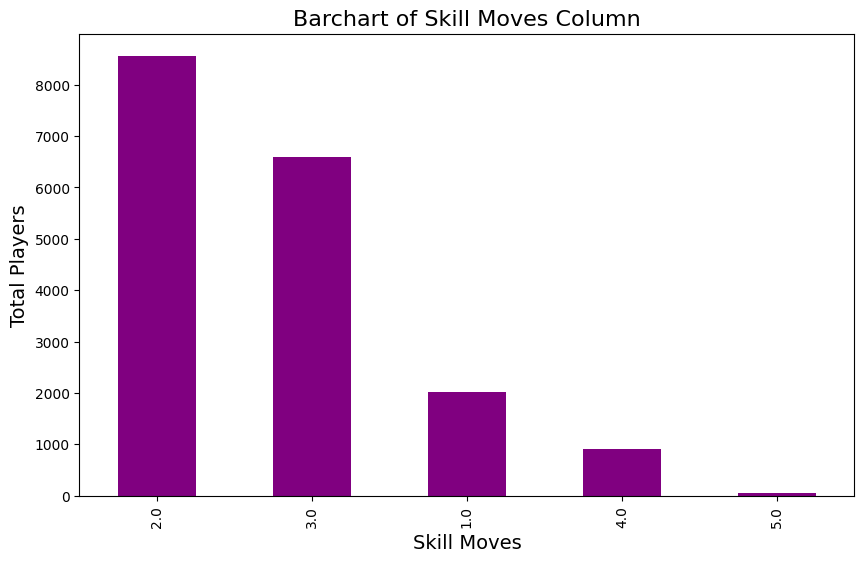

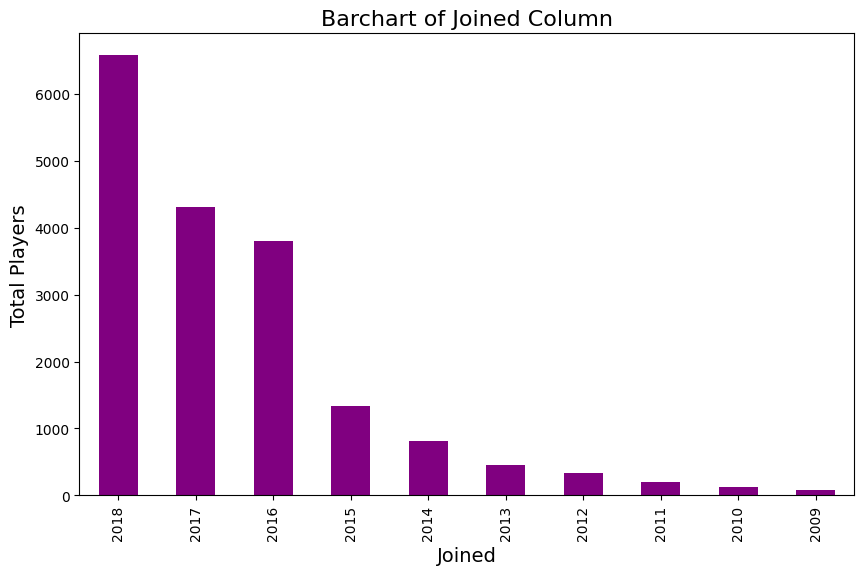

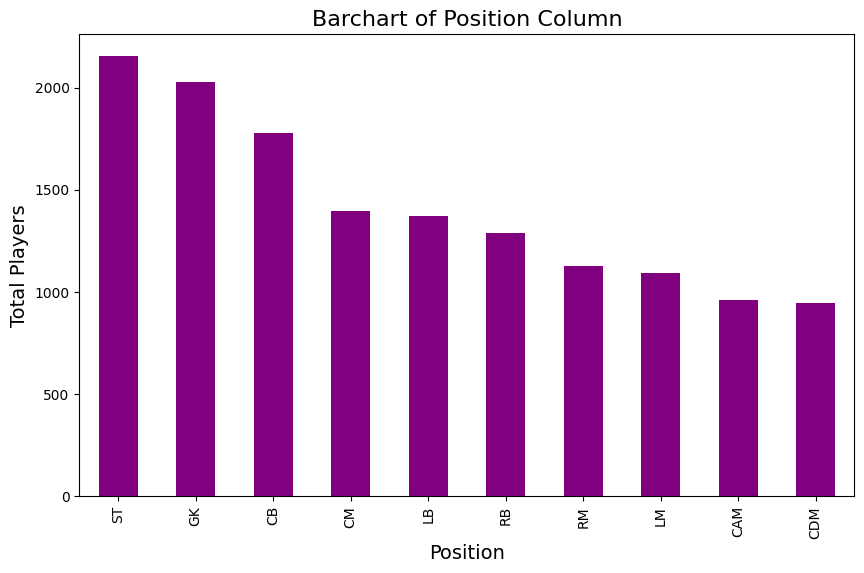

In [ ]:
#Barchart of Categorical Variables:
categorical_cols = ['rating_category', 'listed_in', 'country', 'title', 'cast', 'director', 'type']
for col in categorical_cols:
  BarPlot(df, col)